In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
dhoogla_cicids2017_path = kagglehub.dataset_download('dhoogla/cicids2017')

print('Data source import complete.')


Data source import complete.


In [2]:
# ───────────────────────────────────────────────────────────────────────────────
# DYNAMIC ENVIRONMENT SETUP FOR MULTIPLE GPU/TPU CONFIGURATIONS
# ───────────────────────────────────────────────────────────────────────────────

import os, random, warnings

# 1) GPU/TPU CONFIGURATION
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TF info messages
warnings.filterwarnings("ignore", category=UserWarning)

import tensorflow as tf
import pandas as pd
import numpy as np

# Improved hardware detection
try:
    # First try TPU detection
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    device_type = 'TPU'
    print(f"✅ Using TPU: {tpu.master()}")
except (ValueError, tf.errors.NotFoundError):
    # If TPU not found, check for GPUs
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        # Use all available GPUs
        strategy = tf.distribute.MirroredStrategy()
        device_type = 'GPU'
        print(f"✅ Using {len(gpus)} GPU(s)")
    else:
        # Fallback to CPU
        strategy = tf.distribute.get_strategy()
        device_type = 'CPU'
        print("✅ Using CPU")

print("Visible devices:", tf.config.get_visible_devices())

# 2) PRECISION CONFIGURATION
from tensorflow.keras import mixed_precision

if device_type == 'TPU':
    policy = mixed_precision.Policy('mixed_bfloat16')
    mixed_precision.set_global_policy(policy)
    print(f"✅ Precision: mixed_bfloat16 (required for TPU)")
elif any('gpu' in d.device_type.lower() for d in tf.config.get_visible_devices()):
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
    print(f"✅ Precision: mixed_float16")
else:
    print("✅ Precision: float32 (CPU mode)")

# 3) GPU MEMORY MANAGEMENT (skip for TPU)
if device_type == 'GPU':
    for gpu in tf.config.list_physical_devices('GPU'):
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except:
            pass

    
# 4) PERFORMANCE OPTIMIZATIONS
# Enable XLA compilation
tf.config.optimizer.set_jit(True)

# Configure dataset pipeline
options = tf.data.Options()
options.experimental_optimization.parallel_batch = True
options.threading.private_threadpool_size = min(8, os.cpu_count() or 8)

# 5) REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── PYDATA & ML LIBRARIES ─────────────────────────────────────────────────────

from sklearn.model_selection      import train_test_split
from sklearn.feature_selection    import VarianceThreshold, SelectFromModel
from sklearn.ensemble             import RandomForestClassifier
from sklearn.preprocessing        import StandardScaler, QuantileTransformer, LabelEncoder
from sklearn.decomposition        import PCA
from sklearn.utils                import resample, class_weight
from sklearn.metrics              import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.manifold             import TSNE

# Optional UMAP embedding
try:
    from umap import UMAP
    print("✅ UMAP imported")
except ImportError:
    print("⚠️ UMAP not available")

# ─── DEEP LEARNING UTILITIES ───────────────────────────────────────────────────
from tensorflow.keras             import layers, models, optimizers, callbacks
from tensorflow.data              import Dataset
from tensorflow.python.framework  import convert_to_constants

# ─── IMAGE / AUTOENCODER METRICS ───────────────────────────────────────────────
# Correct installation and import of scikit-image
try:
    from skimage.metrics import peak_signal_noise_ratio as psnr
    from skimage.metrics import structural_similarity as ssim
    print("✅ scikit-image metrics imported")
except ImportError:
    print("Installing scikit-image for image metrics...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-image"])
    from skimage.metrics import peak_signal_noise_ratio as psnr
    from skimage.metrics import structural_similarity as ssim
    print("✅ scikit-image installed and imported")

# ─── PLOTTING ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

print(f"✅ Environment configured | TensorFlow {tf.__version__} | Device: {device_type}")

2026-03-24 12:45:32.594597: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774356332.796904      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774356332.852887      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1774356346.347603      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ Using 1 GPU(s)
Visible devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Precision: mixed_float16
✅ UMAP imported
✅ scikit-image metrics imported
✅ Environment configured | TensorFlow 2.18.0 | Device: GPU


# **Modules and Libs**

# **Data Loading**

In [3]:
import os
import pandas as pd

BASE_PATH = "/kaggle/input/notebooks/yacermeftah/cicids-dataset-processing/cicids2017_processed"

import json

with open(f"{BASE_PATH}/manifest.json") as f:
    manifest = json.load(f)

manifest

train_df = pd.read_parquet(f"{BASE_PATH}/data/train_processed.parquet")
test_df  = pd.read_parquet(f"{BASE_PATH}/data/test_processed.parquet")

print(train_df.shape, test_df.shape)

(1850977, 35) (462745, 35)


In [4]:
X_train = train_df.drop(columns=["LabelEncoded"])
y_train = train_df["LabelEncoded"]

X_test = test_df.drop(columns=["LabelEncoded"])
y_test = test_df["LabelEncoded"]

In [5]:
import joblib

scaler = joblib.load(f"{BASE_PATH}/artifacts/scaler.joblib")
label_encoder = joblib.load(f"{BASE_PATH}/artifacts/label_encoder.joblib")
variance_selector = joblib.load(f"{BASE_PATH}/artifacts/variance_selector.joblib")

In [6]:
with open(f"{BASE_PATH}/artifacts/preprocess_settings.json") as f:
    settings = json.load(f)

settings

{'seed': 42,
 'test_size': 0.2,
 'rare_threshold_pct': 0.1,
 'eps': 1e-06,
 'feature_selection': {'variance_threshold': 0.001,
  'correlation_threshold': 0.9,
  'selected_features': ['Bwd Packet Length Max',
   'Flow IAT Std',
   'Flow Packets/s',
   'Fwd Packet Length Max',
   'Fwd Packets Length Total',
   'Packet_Entropy',
   'Bwd Packets/s',
   'Fwd Packet Length Mean',
   'Fwd Header Length',
   'Flow IAT Mean',
   'Init Bwd Win Bytes',
   'Bwd Header Length',
   'Total Fwd Packets',
   'Fwd Act Data Packets',
   'Burst_Ratio',
   'Flow Duration',
   'Init Fwd Win Bytes',
   'Flow Bytes/s',
   'Active Max',
   'Fwd IAT Min',
   'FIN Flag Count',
   'Active Mean',
   'Bwd IAT Std',
   'Fwd Packet Length Min',
   'Bwd IAT Total',
   'Bwd Packet Length Min',
   'Packet Length Min',
   'Bwd IAT Max',
   'Bwd IAT Mean',
   'Flow IAT Min',
   'Fwd Seg Size Min',
   'Down/Up Ratio',
   'ACK Flag Count',
   'Active Std']},
 'balancing': {'resample_config': {'Benign': 0.5,
   'DoS Hulk': 2

In [7]:
train_labels_original = pd.read_parquet(f"{BASE_PATH}/data/train_labels_original.parquet")
test_labels_original  = pd.read_parquet(f"{BASE_PATH}/data/test_labels_original.parquet")

In [8]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Scaler expects:", scaler.n_features_in_)

Train shape: (1850977, 34)
Test shape: (462745, 34)
Scaler expects: 34


In [9]:
# Scale first
X_train_scaled = scaler.transform(X_train)

# Benign label from your saved mapping
benign_label = settings["label_mapping"]["Benign"]  # usually 0

# Create benign mask from encoded labels
benign_mask = (y_train == benign_label)

# Extract benign samples
X_benign = X_train_scaled[benign_mask].astype(np.float32)

# Sanity check
print(X_benign.shape)

(1581783, 34)


In [10]:
# Scale first
X_test = scaler.transform(X_test)

# Benign label from your saved mapping
benign_label = settings["label_mapping"]["Benign"] 

# Convert y_test in place: 0 = Benign, 1 = Attack
y_test = np.where(y_test == benign_label, 0, 1).astype(np.int64)

In [11]:
print(X_test.shape)
print(y_test.shape)

(462745, 34)
(462745,)


In [12]:
from sklearn.model_selection import train_test_split

X_benign_train, X_benign_val = train_test_split(
    X_benign.astype(np.float32),
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

# **Model Learning**

**Autoencoder**

In [13]:
from tensorflow.keras import layers, initializers, optimizers, callbacks, regularizers
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow_probability as tfp
tfd = tfp.distributions

In [14]:
import seaborn as sns

In [15]:
class Sampling(layers.Layer):
    def __init__(self, kl_weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.kl_weight = tf.Variable(
            initial_value=float(kl_weight),
            trainable=False,
            dtype=tf.float32
        )

    def call(self, inputs, training=None):
        z_mean, z_log_var = inputs
        z_mean = tf.cast(z_mean, tf.float32)
        z_log_var = tf.cast(z_log_var, tf.float32)
        z_log_var = tf.clip_by_value(z_log_var, -20.0, 10.0)

        # KL is always computed
        kl_element = -0.5 * (1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_element, axis=1))
        self.add_loss(self.kl_weight * 0.01 * kl_loss)

        # Stochastic during training, deterministic during validation/inference
        if training:
            eps = tf.random.normal(tf.shape(z_mean), dtype=tf.float32)
            return z_mean + tf.exp(0.5 * z_log_var) * eps
        else:
            return z_mean

In [16]:
class FeatureWeightedLoss(layers.Layer):
    def __init__(self, feature_weights, **kwargs):
        super().__init__(**kwargs)
        w = np.asarray(feature_weights, dtype=np.float32)

        # Normalize weights so the average weight is ~1
        w = w / (np.mean(w) + 1e-8)

        # Clip extreme weights to avoid one feature dominating
        w = np.clip(w, 0.1, 10.0)

        self.feature_weights = tf.constant(w, dtype=tf.float32)

    def call(self, inputs, reconstructions):
        inputs = tf.cast(inputs, tf.float32)
        reconstructions = tf.cast(reconstructions, tf.float32)

        squared_diff = tf.square(inputs - reconstructions)
        weighted_loss = tf.reduce_mean(squared_diff * self.feature_weights, axis=-1)
        return tf.reduce_mean(weighted_loss)

In [17]:
class VAE(tf.keras.Model):
    def __init__(self, input_dim, latent_dim=16, **kwargs):
        super().__init__(**kwargs)
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder
        self.encoder_dense0 = layers.Dense(256)
        self.encoder_bn0    = layers.BatchNormalization()
        self.encoder_act0   = layers.LeakyReLU()

        self.encoder_dense1 = layers.Dense(128)
        self.encoder_bn1    = layers.BatchNormalization()
        self.encoder_act1   = layers.LeakyReLU()

        self.encoder_dense2 = layers.Dense(64)
        self.encoder_bn2    = layers.BatchNormalization()
        self.encoder_act2   = layers.LeakyReLU()

        self.z_mean_layer    = layers.Dense(latent_dim, name="z_mean")
        self.z_log_var_layer = layers.Dense(latent_dim, name="z_log_var")
        self.sampling        = Sampling(name="sampling")

        # Decoder
        self.decoder_dense1 = layers.Dense(64)
        self.decoder_bn1    = layers.BatchNormalization()
        self.decoder_act1   = layers.LeakyReLU()

        self.decoder_dense2 = layers.Dense(128)
        self.decoder_bn2    = layers.BatchNormalization()
        self.decoder_act2   = layers.LeakyReLU()

        self.decoder_dense3 = layers.Dense(256)
        self.decoder_bn3    = layers.BatchNormalization()
        self.decoder_act3   = layers.LeakyReLU()

        self.decoder_output = layers.Dense(input_dim, activation="linear", name="decoder_output")

    def call(self, inputs, training=None):
        # Encoder
        x = self.encoder_dense0(inputs)
        x = self.encoder_bn0(x, training=training)
        x = self.encoder_act0(x)

        x = self.encoder_dense1(x)
        x = self.encoder_bn1(x, training=training)
        x = self.encoder_act1(x)

        x = self.encoder_dense2(x)
        x = self.encoder_bn2(x, training=training)
        x = self.encoder_act2(x)

        z_mean    = self.z_mean_layer(x)
        z_log_var = self.z_log_var_layer(x)
        z         = self.sampling((z_mean, z_log_var), training=training)

        # Decoder
        x = self.decoder_dense1(z)
        x = self.decoder_bn1(x, training=training)
        x = self.decoder_act1(x)

        x = self.decoder_dense2(x)
        x = self.decoder_bn2(x, training=training)
        x = self.decoder_act2(x)

        x = self.decoder_dense3(x)
        x = self.decoder_bn3(x, training=training)
        x = self.decoder_act3(x)

        return self.decoder_output(x)

    def compile(self, optimizer, loss_fn, **kwargs):
        super().compile(**kwargs)
        self.optimizer = optimizer
        self.loss_fn = loss_fn

        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.rec_loss_tracker   = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker    = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.rec_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        x = data if not isinstance(data, tuple) else data[0]

        with tf.GradientTape() as tape:
            reconstruction = self(x, training=True)
            rec_loss = self.loss_fn(x, reconstruction)
            kl_loss = tf.add_n(self.losses) if self.losses else 0.0
            total_loss = rec_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.rec_loss_tracker.update_state(rec_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.rec_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        x = data if not isinstance(data, tuple) else data[0]
        reconstruction = self(x, training=False)
        rec_loss = self.loss_fn(x, reconstruction)
        kl_loss = tf.add_n(self.losses) if self.losses else 0.0
        total_loss = rec_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.rec_loss_tracker.update_state(rec_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.rec_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [18]:
# Base inverse-variance weights
feature_vars = np.var(X_benign_train, axis=0) + 1e-6
some_weights = 1.0 / feature_vars

feature_names = settings["feature_selection"]["selected_features"]

# Normalize to keep the average weight around 1
some_weights = some_weights / (np.mean(some_weights) + 1e-8)

# Prevent a few low-variance features from dominating
some_weights = np.clip(some_weights, 0.25, 4.0)

# Mild feature-specific tuning based on FP/FN diagnostics
feature_tuning = {
    # Strong in both FP and FN -> reduce, but not drastically
    "Packet_Entropy": 0.50,
    "ACK Flag Count": 0.60,
    "Burst_Ratio": 0.70,

    # More FN-driven -> slight boost for sensitivity
    "Fwd Act Data Packets": 1.20,

    # Mostly FP-driven -> small reduction
    "Fwd Packet Length Min": 0.85,
    "Bwd IAT Std": 0.85,

    # Also frequent in both, keep modest
    "Bwd Packet Length Max": 0.95,
    "Bwd Packet Length Min": 0.95,
    "Bwd Header Length": 0.95,
    "Packet Length Min": 0.95,
}

for feat, factor in feature_tuning.items():
    if feat in feature_names:
        idx = feature_names.index(feat)
        some_weights[idx] *= factor

# Final safety clip
some_weights = np.clip(some_weights, 0.25, 4.0)

In [19]:
vae_optimizer = optimizers.Adam(learning_rate=1e-5)
num_features = X_benign.shape[1]
vae = VAE(input_dim=num_features, latent_dim=16)

vae.compile(
    optimizer=vae_optimizer,
    loss_fn=FeatureWeightedLoss(feature_weights=some_weights)
)

In [20]:
class KLCallback(callbacks.Callback):
    def __init__(self, annealing_epochs=30):
        self.annealing_epochs = annealing_epochs

    def on_epoch_begin(self, epoch, logs=None):
        kl_w = min(epoch / self.annealing_epochs, 1.0)
        self.model.sampling.kl_weight.assign(kl_w)
        print(f"\nKL weight: {kl_w:.4f}")

In [21]:
callbacks_list = [
    KLCallback(annealing_epochs=30),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=40,
        restore_best_weights=True,
        min_delta=0.01
    ),
    callbacks.TerminateOnNaN(),
    callbacks.ModelCheckpoint(
        'stable_vae_model.keras',
        save_best_only=True,
        monitor='val_loss'
    )
]

In [22]:
history = vae.fit(
    X_benign_train,
    validation_data=(X_benign_val,),
    epochs=150,
    batch_size=2048,
    callbacks=callbacks_list,
    shuffle=True
)


KL weight: 0.0000
Epoch 1/150


I0000 00:00:1774356390.445395      60 service.cc:148] XLA service 0x7c9520024150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774356390.446206      60 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774356390.474547      60 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1774356390.553758      60 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


618/618 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - kl_loss: 0.0000e+00 - loss: 20.1296 - reconstruction_loss: 20.1296 - val_kl_loss: 0.0000e+00 - val_loss: 15.3030 - val_reconstruction_loss: 15.3030

KL weight: 0.0333
Epoch 2/150
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 0.0396 - loss: 14.2682 - reconstruction_loss: 14.2287 - val_kl_loss: 0.0727 - val_loss: 10.9545 - val_reconstruction_loss: 10.8818

KL weight: 0.0667
Epoch 3/150
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 0.1257 - loss: 10.4910 - reconstruction_loss: 10.3653 - val_kl_loss: 0.1233 - val_loss: 8.3045 - val_reconstruction_loss: 8.1812

KL weight: 0.1000
Epoch 4/150
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 0.1448 - loss: 7.9117 - reconstruction_loss: 7.7669 - val_kl_loss: 0.1259 - val_loss: 6.1955 - val_reconstruction_loss: 6.0696

KL weight: 0.1333
Epoch 5/150
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 0.1413 - loss: 5.8815 - reconstruction_loss: 5.7402 - val_kl_loss: 0.1275 - val_loss: 4.

# **Evaluation**

In [23]:
def reconstruction_score(x, x_pred, feature_weights):
    x = np.asarray(x, dtype=np.float32)
    x_pred = np.asarray(x_pred, dtype=np.float32)
    feature_weights = np.asarray(feature_weights, dtype=np.float32)

    weighted_errors = (x - x_pred) ** 2 * feature_weights
    return np.log1p(np.sum(weighted_errors, axis=1))

In [24]:
# Validation score on benign only
X_val_pred = vae.predict(X_benign_val, batch_size=4096, verbose=0)
val_score = reconstruction_score(X_benign_val, X_val_pred, some_weights)

# Threshold from validation benign distribution
threshold = np.quantile(val_score, 0.99)
print("Threshold:", threshold)

# Test score
X_test_recon = vae.predict(X_test, batch_size=4096, verbose=0)
recon_error = reconstruction_score(X_test, X_test_recon, some_weights)


# 1D predicted labels
y_pred = (recon_error > threshold).astype(int)

Threshold: 2.138385057449341


In [25]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc

print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, recon_error)
precision, recall, thresholds = precision_recall_curve(y_test, recon_error)
pr_auc = auc(recall, precision)
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)

best_threshold = thresholds[np.argmax(
    2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)
)]

print("ROC AUC:", roc_auc)
print("PR AUC:", pr_auc)
print("Best F1 threshold:", best_threshold)

              precision    recall  f1-score   support

           0     0.9432    0.9898    0.9659    395447
           1     0.9155    0.6499    0.7602     67298

    accuracy                         0.9404    462745
   macro avg     0.9294    0.8198    0.8631    462745
weighted avg     0.9392    0.9404    0.9360    462745

ROC AUC: 0.9610009580555772
PR AUC: 0.8741461725978897
Best F1 threshold: 1.4457947


In [26]:
# Calculate squared error per feature for False Positives only
fp_mask = (y_test == 0) & (y_pred == 1)
fp_feature_errors = ((X_test[fp_mask] - X_test_recon[fp_mask]) ** 2) * some_weights
fp_error_ranking = pd.Series(fp_feature_errors.mean(axis=0), index=feature_names).sort_values(ascending=False)

print("Top features causing False Positives:\n", fp_error_ranking.head(10))

Top features causing False Positives:
 Bwd Packet Length Max    0.839826
Bwd IAT Std              0.705664
Bwd Header Length        0.700701
Fwd Packet Length Min    0.496097
Fwd Header Length        0.469445
Total Fwd Packets        0.407807
Bwd Packet Length Min    0.401316
Fwd Packet Length Max    0.400805
Flow Bytes/s             0.390372
Packet_Entropy           0.372869
dtype: float64


In [27]:
# Calculate squared error per feature for False Positives only
fn_mask = (y_test == 1) & (y_pred == 0)
fn_feature_errors = ((X_test[fn_mask] - X_test_recon[fn_mask]) ** 2) * some_weights
fn_error_ranking = pd.Series(fn_feature_errors.mean(axis=0), index=feature_names).sort_values(ascending=False)

print("Top features causing False Positives:\n", fn_error_ranking.head(10))

Top features causing False Positives:
 Bwd Packet Length Max    0.509469
Fwd Act Data Packets     0.429221
Fwd Header Length        0.412141
Burst_Ratio              0.194721
Fwd Seg Size Min         0.155561
Down/Up Ratio            0.153856
Flow Packets/s           0.148567
Flow IAT Min             0.141859
Init Bwd Win Bytes       0.139714
ACK Flag Count           0.117612
dtype: float64


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [29]:
def plot_cm(y_true, y_pred, labels, title="Confusion Matrix"):
    """Helper to plot a clean heatmap confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

[[391412   4035]
 [ 23561  43737]]


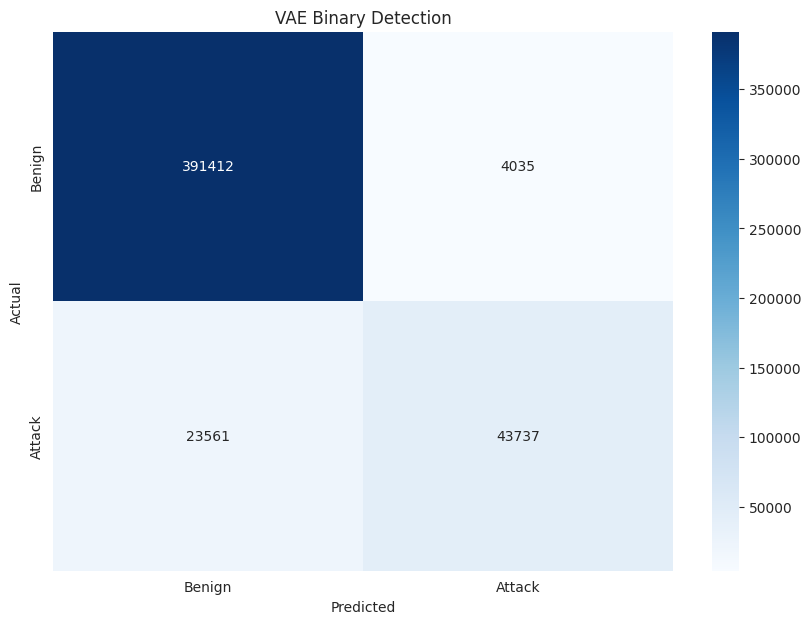

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

plot_cm(y_test, y_pred, labels=['Benign', 'Attack'], title="VAE Binary Detection")

In [31]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, recon_error)
print("ROC AUC:", roc_auc)

ROC AUC: 0.9610009580555772


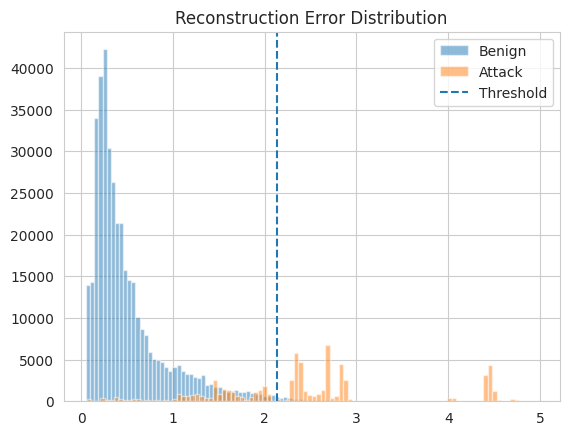

In [32]:
import matplotlib.pyplot as plt

plt.hist(recon_error[y_test == 0], bins=100, alpha=0.5, label="Benign")
plt.hist(recon_error[y_test == 1], bins=100, alpha=0.5, label="Attack")
plt.axvline(threshold, linestyle='--', label='Threshold')

plt.legend()
plt.title("Reconstruction Error Distribution")
plt.show()

# **Save artifacts**

In [33]:
vae.save("vae_cicids.keras")
import joblib

joblib.dump(threshold, "vae_threshold.joblib")
joblib.dump(scaler, "vae_scaler.joblib")
import json

config = {
    "input_dim": num_features,
    "latent_dim": 16,
    "threshold": float(threshold),
    "features": list(X_train.columns),
    "scaling": settings["scaling"],
    "seed": SEED
}

with open("vae_config.json", "w") as f:
    json.dump(config, f, indent=4)
joblib.dump(history.history, "vae_history.joblib")

['vae_history.joblib']